# 08 — `Spectrogram`: STFT magnitude on a chirp

Per-channel STFT wrapper. Returns `(spectrograms, freqs, times)`
where `spectrograms` is shaped `(B, C, F, T)`. Window defaults
to Hann, `hop_length` defaults to `n_fft // 4`.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.signal import chirp

import scitex_nn

fs, duration, n_fft = 500, 2.0, 256
seq_len = int(fs * duration)
t = np.arange(seq_len) / fs
sig = chirp(t, f0=5, t1=t[-1], f1=60).astype(np.float32)
x = torch.from_numpy(sig).view(1, 1, -1)

## STFT magnitude with the instantaneous-frequency overlay

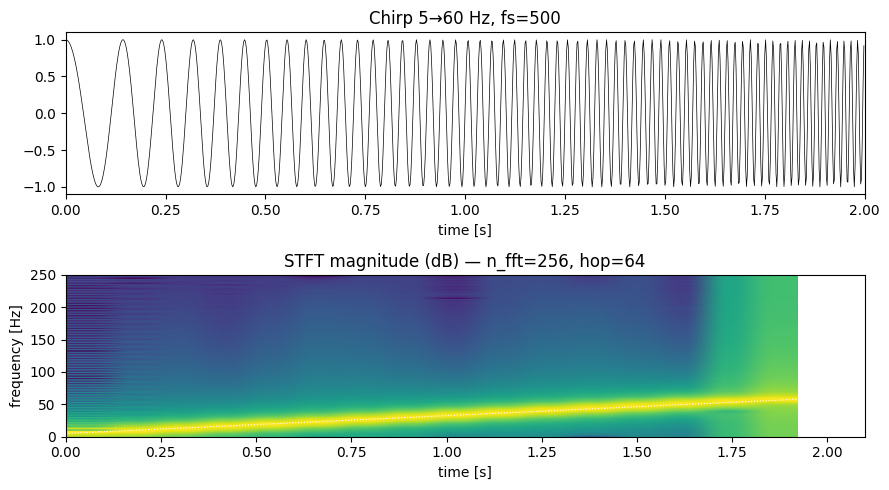

In [2]:
sg = scitex_nn.Spectrogram(sampling_rate=fs, n_fft=n_fft)
spec, freqs, times = sg(x)
spec_db = 20 * torch.log10(spec.squeeze() + 1e-10)

fig, axes = plt.subplots(2, 1, figsize=(9, 5))
axes[0].plot(t, sig, "k", lw=0.5)
axes[0].set_xlim(0, duration)
axes[0].set_xlabel("time [s]")
axes[0].set_title(f"Chirp 5→60 Hz, fs={fs}")

axes[1].imshow(
    spec_db.numpy(),
    aspect="auto",
    origin="lower",
    extent=(0, float(times[-1]), 0, float(freqs[-1])),
    cmap="viridis",
)
axes[1].plot(t, np.linspace(5, 60, seq_len), color="white", ls=":", lw=0.8)
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("frequency [Hz]")
axes[1].set_title(f"STFT magnitude (dB) — n_fft={n_fft}, hop={n_fft // 4}")
fig.tight_layout()
plt.show()